In [231]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torchvision import transforms


In [201]:
train_df = pd.read_csv('../sign_lang_recognition/data/sign_mnist_train.csv')
test_df = pd.read_csv('../sign_lang_recognition/data/sign_mnist_test.csv')

train_labels = train_df['label'].values
train_images = train_df.drop('label', axis=1).values

test_labels = test_df['label'].values
test_images = test_df.drop('label', axis=1).values

In [202]:
train_imgs, val_imgs, train_lbls, val_lbls = train_test_split(
  train_images, train_labels,
  test_size=0.15,
  stratify=train_labels,
  random_state=42
)

In [203]:
class SignLanguageDataset(Dataset):
  def __init__(self, images, labels, transform=None):
    self.images = images
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    image = self.images[idx].reshape(28, 28).astype(np.uint8)
    label = torch.tensor(self.labels[idx], dtype=torch.long)

    if self.transform:
      image = self.transform(image)
    else:
      image = torch.tensor(image, dtype=torch.float32) / 255.0
      image = image.unsqueeze(0)

    return image, label

In [204]:
train_transform = transforms.Compose([
  transforms.ToPILImage(),
  transforms.RandomRotation(10),
  transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
  transforms.ToPILImage(),
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,))
])

In [205]:
train_dataset = SignLanguageDataset(train_imgs, train_lbls, transform=train_transform)
val_dataset = SignLanguageDataset(val_imgs, val_lbls, transform=test_transform)
test_dataset = SignLanguageDataset(test_images, test_labels, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [206]:
def train_model(model, epochs=10):
  optimizer = optim.Adam(model.parameters(), lr=0.001)
  loss_fn = nn.CrossEntropyLoss()

  best_val_acc = 0

  train_acc_list = []   
  val_acc_list = []     

  for epoch in range(epochs):
    model.train()
    train_correct, train_total = 0, 0

    for imgs, labels in train_loader:
      preds = model(imgs)
      loss = loss_fn(preds, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_correct += (preds.argmax(1) == labels).sum().item()
      train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_acc_list.append(train_acc)

    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
      for imgs, labels in val_loader:
        preds = model(imgs)
        val_correct += (preds.argmax(1) == labels).sum().item()
        val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}: Train={train_acc:.4f}, Val={val_acc:.4f}")

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_weights = model.state_dict()

  model.load_state_dict(best_weights)
  print("Best Val Accuracy:", best_val_acc)

  return train_acc_list, val_acc_list, best_val_acc

In [207]:
def test_model(model):

  model.eval()

  correct = 0
  total = 0

  with torch.no_grad():
    for imgs, labels in test_loader:
      outputs = model(imgs)
      predicted = outputs.argmax(dim=1)
      correct += (predicted == labels).sum().item()
      total += labels.size(0)

  accuracy = correct / total
  print("Test Accuracy:", accuracy)
  return accuracy

In [208]:
def count_params(model):
  return sum(p.numel() for p in model.parameters())


In [209]:
class BaseCNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 8, kernel_size = 3, padding=1)
    self.act1 = nn.Tanh()
    self.pool1 = nn.MaxPool2d(2)

    self.conv2 = nn.Conv2d(8, 16, kernel_size = 3, padding=1)
    self.act2 = nn.Tanh()
    self.pool2 = nn.MaxPool2d(2)

    self.fc1 = nn.Linear(16*7*7, 32)
    self.act3 = nn.Tanh()
    self.fc2 = nn.Linear(32, 25)

  def forward(self, x):
    x = x.view(x.size(0), 1, 28, 28)
    x = self.pool1(self.act1(self.conv1(x)))
    x = self.pool2(self.act2(self.conv2(x)))
    x = x.view(x.size(0), -1)
    x = self.fc2(self.act3(self.fc1(x)))

    return x


In [210]:
base_cnn = BaseCNN()
base_train, base_val, base_best_val = train_model(base_cnn)
# base_cnn_test_accuracy = test_model(base_cnn)
print("CNN Parameters: ", count_params(base_cnn))

Epoch 1: Train=0.3767, Val=0.6931
Epoch 2: Train=0.6554, Val=0.8291
Epoch 3: Train=0.7636, Val=0.8946
Epoch 4: Train=0.8246, Val=0.9342
Epoch 5: Train=0.8652, Val=0.9658
Epoch 6: Train=0.8915, Val=0.9748
Epoch 7: Train=0.9112, Val=0.9888
Epoch 8: Train=0.9244, Val=0.9883
Epoch 9: Train=0.9366, Val=0.9913
Epoch 10: Train=0.9418, Val=0.9961
Best Val Accuracy: 0.9961155620296188
CNN Parameters:  27193


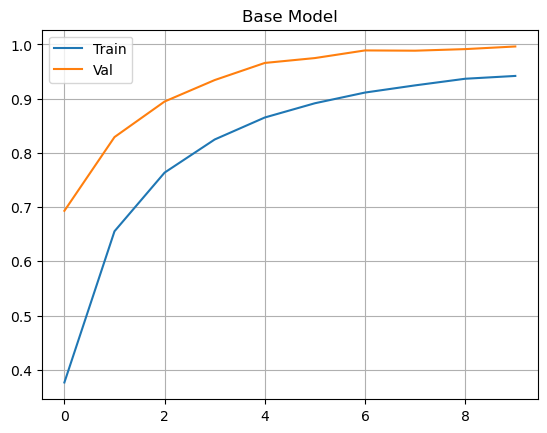

In [211]:
plt.figure()
plt.plot(base_train, label="Train")
plt.plot(base_val, label="Val")
plt.title("Base Model")
plt.legend()
plt.grid()
plt.show()

The Base CNN was able to reach a high validation accuracy. However, since the training accuracy continues to increase across epochs, which suggests that the model could be learning dataset specific patterns. Because of this, I tried to introduce a dropout as a regularization technique. Since Dropout randomly deactivates neurons during training, it could help prevent the model from relying too much on specific features, which can help generalization and reduce any overfitting.

In [212]:
class DropoutCNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
    self.act1 = nn.Tanh()
    self.pool1 = nn.MaxPool2d(2)
    self.dropout1 = nn.Dropout2d(0.4)

    self.conv2 = nn.Conv2d(8, 16, kernel_size = 3, padding=1)
    self.act2 = nn.Tanh()
    self.pool2 = nn.MaxPool2d(2)
    self.dropout2 = nn.Dropout2d(0.4)

    self.fc1 = nn.Linear(16*7*7, 32)
    self.act3 = nn.Tanh()
    self.fc2 = nn.Linear(32, 25)

  def forward(self, x):
    x = x.view(x.size(0), 1, 28, 28)
    x = self.pool1(self.act1(self.conv1(x)))
    x = self.dropout1(x)
    x = self.pool2(self.act2(self.conv2(x)))
    x = self.dropout2(x)
    x = x.view(x.size(0), -1)
    x = self.fc2(self.act3(self.fc1(x)))

    return x

In [213]:
cnn_dropout = DropoutCNN()
dropout_train, dropout_val, best_dropout_val = train_model(cnn_dropout)
# cnn_dropout_test_accuracy = test_model(cnn_dropout)
print("CNN Parameters: ", count_params(cnn_dropout))

Epoch 1: Train=0.2982, Val=0.5603
Epoch 2: Train=0.4936, Val=0.7327
Epoch 3: Train=0.5784, Val=0.8148
Epoch 4: Train=0.6271, Val=0.8415
Epoch 5: Train=0.6616, Val=0.8665
Epoch 6: Train=0.6845, Val=0.8963
Epoch 7: Train=0.6999, Val=0.9111
Epoch 8: Train=0.7236, Val=0.9194
Epoch 9: Train=0.7269, Val=0.9213
Epoch 10: Train=0.7391, Val=0.9364
Best Val Accuracy: 0.9363923282350085
CNN Parameters:  27193


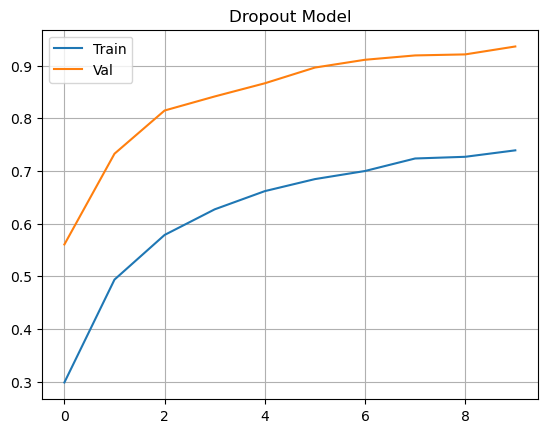

In [214]:
plt.figure()
plt.plot(dropout_train, label="Train")
plt.plot(dropout_val, label="Val")
plt.title("Dropout Model")
plt.legend()
plt.grid()
plt.show()

After introducing dropout, the validation accuracy decreased significantly, which could mean that the model is now underfitting the data so the model is not able to learn meaningful patterns from the training set. Because of this, I wanted to explore changing the activation function from Tanh to ReLU to improve the training efficiency.

In [215]:
class ReLUCNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 8, kernel_size = 3, padding=1)
    self.act1 = nn.ReLU()
    self.pool1 = nn.MaxPool2d(2)

    self.conv2 = nn.Conv2d(8, 16, kernel_size = 3, padding=1)
    self.act2 = nn.ReLU()
    self.pool2 = nn.MaxPool2d(2)

    self.fc1 = nn.Linear(16*7*7, 32)
    self.act3 = nn.ReLU()
    self.fc2 = nn.Linear(32, 25)

  def forward(self, x):
    x = x.view(x.size(0), 1, 28, 28)
    x = self.pool1(self.act1(self.conv1(x)))
    x = self.pool2(self.act2(self.conv2(x)))
    x = x.view(x.size(0), -1)
    x = self.fc2(self.act3(self.fc1(x)))

    return x


In [216]:
cnn_relu = ReLUCNN()
relu_train, relu_val, best_relu_val = train_model(cnn_relu)
# cnn_relu_test_accuracy = test_model(cnn_relu)
print("CNN Parameters: ", count_params(cnn_relu))

Epoch 1: Train=0.3156, Val=0.6536
Epoch 2: Train=0.6363, Val=0.8075
Epoch 3: Train=0.7341, Val=0.8560
Epoch 4: Train=0.7913, Val=0.8985
Epoch 5: Train=0.8261, Val=0.8992
Epoch 6: Train=0.8500, Val=0.9405
Epoch 7: Train=0.8702, Val=0.9347
Epoch 8: Train=0.8848, Val=0.9592
Epoch 9: Train=0.8947, Val=0.9580
Epoch 10: Train=0.9005, Val=0.9578
Best Val Accuracy: 0.9592134013109979
CNN Parameters:  27193


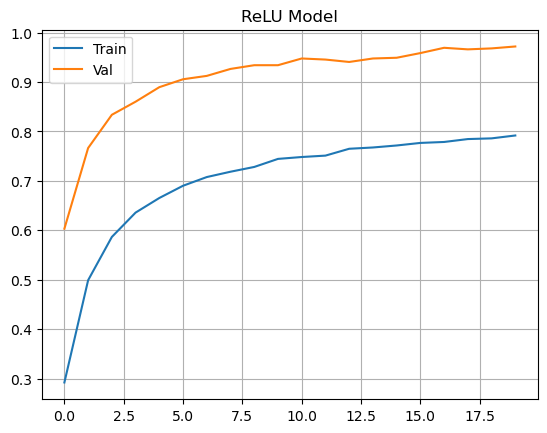

In [179]:
plt.figure()
plt.plot(dropout_train, label="Train")
plt.plot(dropout_val, label="Val")
plt.title("ReLU Model")
plt.legend()
plt.grid()
plt.show()

Replacing Tanh with ReLU decreased the model’s validation accuracy from the base model, which means that the activation function was not the main limiting factor in the model. This probably means that the issue is most likely related to the model’s capacity rather than its ability to optimize gradients and capture the complexity of the data. Because of this, I next increased the width of the CNN by adding more filters in the convolutional layers. A wider network can learn more features at each layer, which could be useful in this case.


In [217]:
class WideCNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 32, kernel_size=3,padding=1)
    self.act1 = nn.Tanh()
    self.pool1 = nn.MaxPool2d(2)

    self.conv2 = nn.Conv2d(32,16, kernel_size=3,padding=1)
    self.act2 = nn.Tanh()
    self.pool2 = nn.MaxPool2d(2)

    self.fc1 = nn.Linear(16*7*7,64)
    self.act3 = nn.Tanh()
    self.fc2 = nn.Linear(64,25)

  def forward(self,x):

    x = x.view(x.size(0), 1, 28, 28)
    x = self.pool1(self.act1(self.conv1(x)))
    x = self.pool2(self.act2(self.conv2(x)))
    x = x.view(x.size(0), -1)
    x = self.fc2(self.act3(self.fc1(x)))

    return x

In [218]:
cnn_wide = WideCNN()
wide_train, wide_val, best_wide_val = train_model(cnn_wide)
# cnn_wide_test_accuracy = test_model(cnn_wide)
print("CNN Parameters: ", count_params(cnn_wide))

Epoch 1: Train=0.4962, Val=0.8517
Epoch 2: Train=0.7996, Val=0.9233
Epoch 3: Train=0.8878, Val=0.9760
Epoch 4: Train=0.9262, Val=0.9879
Epoch 5: Train=0.9440, Val=0.9910
Epoch 6: Train=0.9562, Val=0.9951
Epoch 7: Train=0.9648, Val=0.9947
Epoch 8: Train=0.9714, Val=0.9985
Epoch 9: Train=0.9742, Val=0.9985
Epoch 10: Train=0.9763, Val=0.9995
Best Val Accuracy: 0.9995144452537024
CNN Parameters:  56809


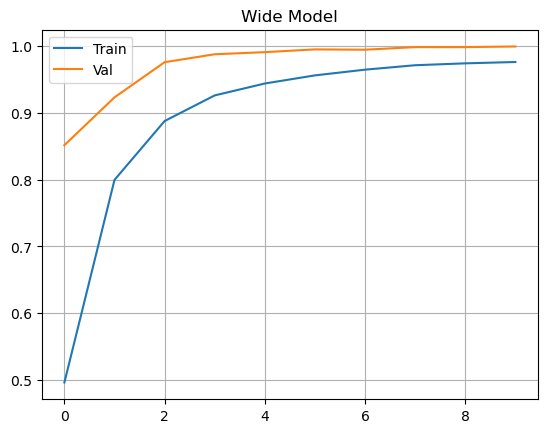

In [219]:
plt.figure()
plt.plot(wide_train, label="Train")
plt.plot(wide_val, label="Val")
plt.title("Wide Model")
plt.legend()
plt.grid()
plt.show()

After increasing the width of the CNN, the validation accuracy improved significantly compared to previous models, which means the original Base CNN did not have enough capacity to learn the complexity of the dataset, and adding more filters allowed the network to learn more. However, at the same time, there was a significant increase in the number of parameters used (almost double). Additionally, the model was able to reach a high accuracy in just a few epochs. Because of this, I wanted to explore whether increasing the depth of the network, instead of the width, could also help the model's performance since deeper models can capture more hierarchal feature representations.

In [220]:
class DeepCNN(nn.Module):

  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1,16,3,padding=1)
    self.act1 = nn.Tanh()

    self.conv2 = nn.Conv2d(16,16,3,padding=1)
    self.act2 = nn.Tanh()

    self.pool1 = nn.MaxPool2d(2)

    self.conv3 = nn.Conv2d(16,8,3,padding=1)
    self.act3 = nn.Tanh()

    self.pool2 = nn.MaxPool2d(2)

    self.fc1 = nn.Linear(8*7*7,32)
    self.fc2 = nn.Linear(32,25)

  def forward(self,x):

    x = x.view(x.size(0), 1, 28, 28)
    x = self.act1(self.conv1(x))
    x = self.act2(self.conv2(x))
    x = self.pool1(x)
    x = self.pool2(self.act3(self.conv3(x)))
    x = x.view(x.size(0), -1)
    x = self.fc2(self.fc1(x))

    return x

In [221]:
cnn_deep = DeepCNN()
deep_train, deep_val, best_deep_val = train_model(cnn_deep)
# cnn_deep_test_accuracy = test_model(cnn_deep)
print("CNN Parameters: ", count_params(cnn_deep))

Epoch 1: Train=0.4303, Val=0.7953
Epoch 2: Train=0.7269, Val=0.8609
Epoch 3: Train=0.8143, Val=0.9158
Epoch 4: Train=0.8590, Val=0.9410
Epoch 5: Train=0.8842, Val=0.9517
Epoch 6: Train=0.9025, Val=0.9592
Epoch 7: Train=0.9159, Val=0.9845
Epoch 8: Train=0.9265, Val=0.9687
Epoch 9: Train=0.9301, Val=0.9852
Epoch 10: Train=0.9366, Val=0.9888
Best Val Accuracy: 0.9888322408351542
CNN Parameters:  17041


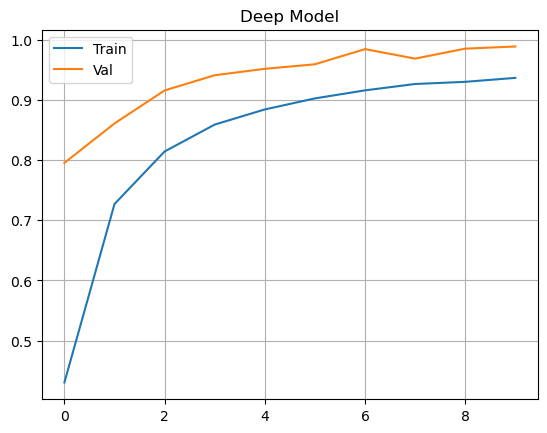

In [222]:
plt.figure()
plt.plot(deep_train, label="Train")
plt.plot(deep_val, label="Val")
plt.title("Deep Model")
plt.legend()
plt.grid()
plt.show()

The test accuracy of the deeper model was lower than that of the wider model, which means that increasing the depth of the network did nothing to the performance of the model. Although the wider CNN achieved the highest test accuracy so far, this could be mainly because of the increased number of parameters.To address this and build a more parameter-efficient model, I introduced Global Average Pooling (GAP). Instead of flattening large feature maps, the GAP layer reduces each feature map to a smaller spatial representation, thereby decreasing the number of parameters in the fully connected layers.

In [223]:
class GAPCNN(nn.Module):

  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1,8,3,padding=1)
    self.act1 = nn.Tanh()
    self.pool1 = nn.MaxPool2d(2)

    self.conv2 = nn.Conv2d(8,16,3,padding=1)
    self.act2 = nn.Tanh()
    self.pool2 = nn.MaxPool2d(2)

    self.gap = nn.AdaptiveAvgPool2d((3,3))

    self.fc1 = nn.Linear(16*3*3,32)
    self.act3 = nn.Tanh()
    self.fc2 = nn.Linear(32,25)

  def forward(self,x):

    x = x.view(x.size(0),1,28,28)
    x = self.pool1(self.act1(self.conv1(x)))
    x = self.pool2(self.act2(self.conv2(x)))
    x = self.gap(x)
    x = x.view(x.size(0),-1)
    x = self.fc2(self.act3(self.fc1(x)))

    return x

In [224]:
cnn_gap = GAPCNN()
gap_train, gap_val, best_gap_val = train_model(cnn_gap)
# cnn_gap_test_accuracy = test_model(cnn_gap)
print("CNN Parameters:", count_params(cnn_gap))

Epoch 1: Train=0.1775, Val=0.3443
Epoch 2: Train=0.4153, Val=0.5778
Epoch 3: Train=0.5636, Val=0.6691
Epoch 4: Train=0.6533, Val=0.7383
Epoch 5: Train=0.7071, Val=0.7820
Epoch 6: Train=0.7511, Val=0.8271
Epoch 7: Train=0.7779, Val=0.8378
Epoch 8: Train=0.8036, Val=0.8704
Epoch 9: Train=0.8208, Val=0.8820
Epoch 10: Train=0.8392, Val=0.9070
Best Val Accuracy: 0.907016266084001
CNN Parameters: 6713


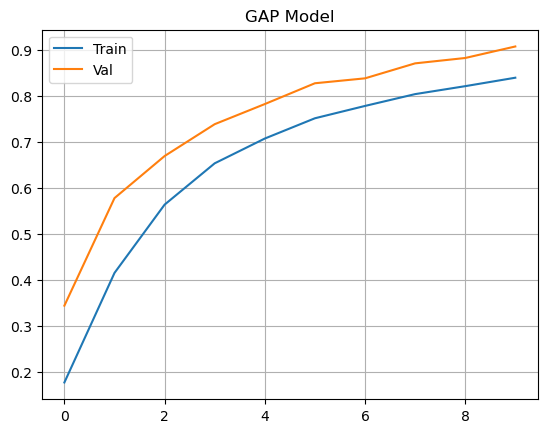

In [255]:
plt.figure()
plt.plot(gap_train, label="Train")
plt.plot(gap_val, label="Val")
plt.title("GAP Model")
plt.legend()
plt.grid()
plt.show()

While the GAP model significantly reduced the number of parameters, it also resulted in a drop in validation accuracy. To try to improve performance without increasing model size, I tried to implement a residual connection in the GAP CNN because residual connections help the network be able learn and identify networks mappings more quickly, increasing training efficiency without adding many extra parameters because the residual adds an element wise addition instead of convolutional layers, thereby decreasing the amount of extra parameters.

In [232]:
class ResidualGAPCNN(nn.Module):
  
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 8, 3, padding = 1)
    self.bn1 = nn.BatchNorm2d(8)
    self.act1 = nn.Tanh()

    self.conv2 = nn.Conv2d(8, 8, 3, padding = 1)
    self.bn2 = nn.BatchNorm2d(8)
    self.act2 = nn.Tanh()
    self.pool = nn.MaxPool2d(2)

    self.conv3 = nn.Conv2d(8, 16, 3, padding = 1)
    self.bn3 = nn.BatchNorm2d(16)
    self.act3 = nn.Tanh()

    self.gap = nn.AdaptiveAvgPool2d((3,3))
    self.gmp = nn.AdaptiveMaxPool2d((3,3))

    self.fc1 = nn.Linear(16*3*3*2, 32)
    self.act_fc = nn.Tanh()
    self.fc2 = nn.Linear(32, 25)

  def forward(self, x):
    x = x.view(x.size(0), 1, 28, 28)
    out1 = self.act1(self.bn1(self.conv1(x)))
    out2 = self.act2(self.bn2(self.conv2(out1))) + out1
    out2 = self.pool(out2)
    out3 = self.act3(self.bn3(self.conv3(out2)))
    out3 = self.pool(out3)
    gap = self.gap(out3)
    gmp = self.gmp(out3)
    x = torch.cat([gap, gmp], dim = 1)
    x = x.view(x.size(0), -1)
    x = self.act_fc(self.fc1(x))
    x = self.fc2(x)

    return x

In [229]:
cnn_residual_gap = ResidualGAPCNN()
res_gap_train, res_gap_val, best_res_gap_val = train_model(cnn_residual_gap)
# cnn_res_gap_test_accuracy = test_model(cnn_residual_gap)
print("CNN Parameters:", count_params(cnn_residual_gap))

Epoch 1: Train=0.3527, Val=0.5601
Epoch 2: Train=0.6463, Val=0.7786
Epoch 3: Train=0.7575, Val=0.8276
Epoch 4: Train=0.8136, Val=0.8844
Epoch 5: Train=0.8485, Val=0.9226
Epoch 6: Train=0.8771, Val=0.9335
Epoch 7: Train=0.8963, Val=0.9335
Epoch 8: Train=0.9110, Val=0.9580
Epoch 9: Train=0.9191, Val=0.9619
Epoch 10: Train=0.9272, Val=0.9670
Best Val Accuracy: 0.9669822772517601
CNN Parameters: 11969


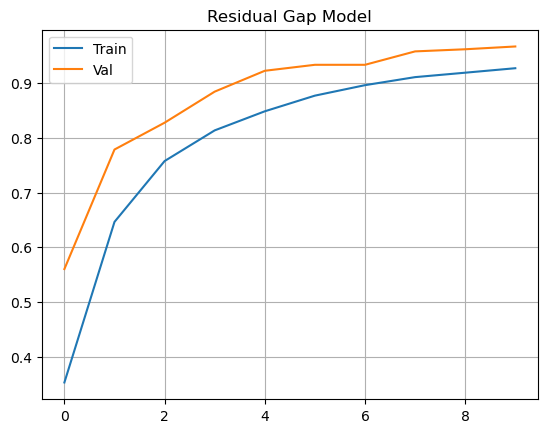

In [230]:
plt.figure()
plt.plot(res_gap_train, label="Train")
plt.plot(res_gap_val, label="Val")
plt.title("Residual Gap Model")
plt.legend()
plt.grid()
plt.show()

Adding the residual connections to the GAP CNN model really help improve the validation accuracy while still keeping the parameter count lower than the previous Wide CNN models. To continue to improve generalization, I tried data augmentation by adding small rotations and translations before the model.

In [233]:
class AugmentationSignLanguageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].reshape(28, 28).astype(np.uint8)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.transform:
            image = self.transform(image)
        else:
            image = torch.tensor(image, dtype=torch.float32) / 255.0
            image = image.unsqueeze(0)

        return image, label

In [234]:
augmentation_strategy = transforms.Compose([
    transforms.ToTensor(),
    # Randomly rotate the image by up to 10 degrees in either direction
    transforms.RandomRotation(degrees=10), 
    # Randomly translate/shift the image vertically or horizontally by up to 10%
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)) 
])

# For testing/validation, we ONLY convert to tensor. We NEVER augment test data.
base_transform = transforms.Compose([
    transforms.ToTensor()
])

aug_train_dataset = AugmentationSignLanguageDataset(
    train_imgs, train_lbls, transform=augmentation_strategy
)

aug_train_loader = DataLoader(aug_train_dataset, batch_size=64, shuffle=True)

In [238]:
def augmented_train_model(model, val_loader, num_epochs=10):
  optimizer = optim.Adam(model.parameters(), lr=0.001)
  loss_function = nn.CrossEntropyLoss()

  train_acc_list = []  
  val_acc_list = [] 
  best_val_acc = 0
  best_weights = None   

  for epoch in range(num_epochs):
    model.train()

    train_correct = 0
    train_total = 0
    

    for imgs, labels in aug_train_loader:
      preds = model(imgs)
      loss = loss_function(preds, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      predicted = preds.argmax(dim=1)
      train_correct += (predicted == labels).sum().item()
      train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_acc_list.append(train_acc)

    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
      for imgs, labels in val_loader:
        preds = model(imgs)
        predicted = preds.argmax(dim=1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_acc_list.append(val_acc)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_weights = model.state_dict()

    print(f"Epoch {epoch+1}: Train Accuracy={train_acc:.4f}, Val Accuracy={val_acc:.4f}")

  model.load_state_dict(best_weights)
  print("Best Val Accuracy:", best_val_acc)
  
  return train_acc_list, val_acc_list, best_val_acc

In [239]:
cnn_gap_aug = ResidualGAPCNN()
gap_aug_train, gap_aug_val, best_gap_aug_val = augmented_train_model(cnn_gap_aug, val_loader)
# cnn_test_accuracy_aug = test_model(cnn_gap_aug)
print("CNN Parameters:", count_params(cnn_gap_aug))

Epoch 1: Train Accuracy=0.3435, Val Accuracy=0.4212
Epoch 2: Train Accuracy=0.6586, Val Accuracy=0.5970
Epoch 3: Train Accuracy=0.7749, Val Accuracy=0.7288
Epoch 4: Train Accuracy=0.8302, Val Accuracy=0.7844
Epoch 5: Train Accuracy=0.8653, Val Accuracy=0.7563
Epoch 6: Train Accuracy=0.8897, Val Accuracy=0.8191
Epoch 7: Train Accuracy=0.9104, Val Accuracy=0.7878
Epoch 8: Train Accuracy=0.9196, Val Accuracy=0.8228
Epoch 9: Train Accuracy=0.9338, Val Accuracy=0.8269
Epoch 10: Train Accuracy=0.9396, Val Accuracy=0.8143
Best Val Accuracy: 0.8268997329448895
CNN Parameters: 11969


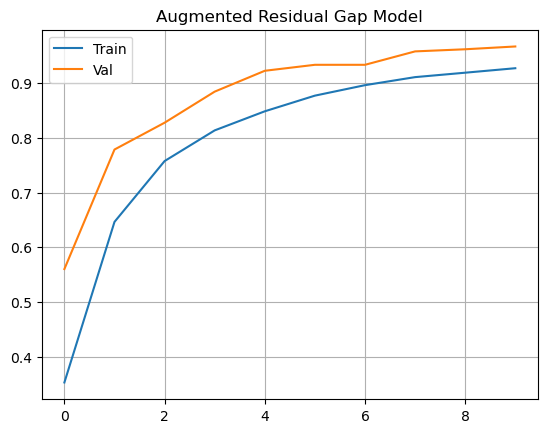

In [240]:
plt.figure()
plt.plot(res_gap_train, label="Train")
plt.plot(res_gap_val, label="Val")
plt.title("Augmented Residual Gap Model")
plt.legend()
plt.grid()
plt.show()

This first augmentation strategy did not work as well because it consisted of relatively strong transformations (rotations of 10 degree and translations of 10 degrees of image size). The testing accuracy went really low because many of these signs migh have subtle differences in finger positions, so these transformations may have distorted any patterns significantly, making it harder for the model to learn meaningful features. Because of this, the second augmentation uses smaller rotations and translations (5 degrees), which help introduce variability in the training data, but also preserve the shapes of the signs.

In [241]:
def augmented_train_model2(model, val_loader, num_epochs=10, lr = 0.001):
  optimizer = optim.Adam(model.parameters(), lr = lr)
  loss_function = nn.CrossEntropyLoss()

  best_val_acc = 0
  train_acc_list = []
  val_acc_list = []

  for epoch in range(num_epochs):
    model.train()
    train_correct = 0
    train_total = 0

    for imgs, labels in aug_train_loader:
      preds = model(imgs)
      loss = loss_function(preds, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      predicted = preds.argmax(dim=1)
      train_correct += (predicted == labels).sum().item()
      train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_acc_list.append(train_acc)

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
      for imgs, labels in val_loader:
        preds = model(imgs)
        predicted = preds.argmax(dim = 1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_acc_list.append(val_acc)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_weights = model.state_dict()

    print(f"Epoch {epoch+1}: Train Accuracy={train_acc:.4f}, Val Accuracy={val_acc:.4f}")

  model.load_state_dict(best_weights)
  print("Best Val Accuracy:", best_val_acc)
  return train_acc_list, val_acc_list, best_val_acc


In [242]:
cnn_gap_aug2 = ResidualGAPCNN()  
gap_aug2_train, gap_aug2_val, best_gap_aug2_val = augmented_train_model2(cnn_gap_aug2, val_loader)
# cnn_test_accuracy_aug = test_model(cnn_gap_aug2)
print("CNN Parameters:", count_params(cnn_gap_aug2))


Epoch 1: Train Accuracy=0.3289, Val Accuracy=0.3506
Epoch 2: Train Accuracy=0.6225, Val Accuracy=0.5159
Epoch 3: Train Accuracy=0.7417, Val Accuracy=0.6086
Epoch 4: Train Accuracy=0.8052, Val Accuracy=0.6934
Epoch 5: Train Accuracy=0.8467, Val Accuracy=0.7359
Epoch 6: Train Accuracy=0.8738, Val Accuracy=0.7286
Epoch 7: Train Accuracy=0.9024, Val Accuracy=0.7429
Epoch 8: Train Accuracy=0.9152, Val Accuracy=0.8424
Epoch 9: Train Accuracy=0.9284, Val Accuracy=0.8208
Epoch 10: Train Accuracy=0.9368, Val Accuracy=0.8041
Best Val Accuracy: 0.8424374848264142
CNN Parameters: 11969


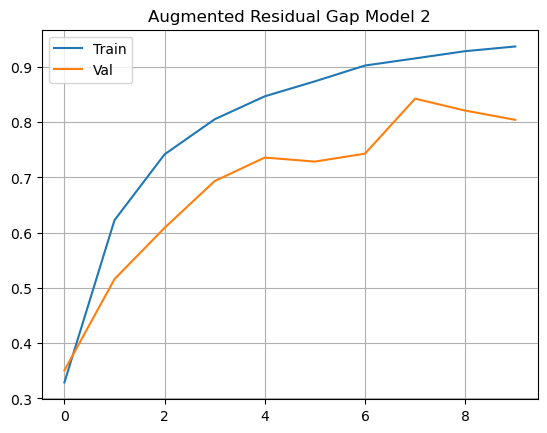

In [243]:
plt.figure()
plt.plot(gap_aug2_train, label="Train")
plt.plot(gap_aug2_val, label="Val")
plt.title("Augmented Residual Gap Model 2")
plt.legend()
plt.grid()
plt.show()

This was able to improve test accuracy compared to the previous agumentation. To increase it more, I refined my training process more by using more milder augmentations to introduce some variability but also avoiding distorting the images too much. I also combined both the original dataset and the augmented one durng training to allow the model to learn from the true distribution.  

In [244]:
mild_aug_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(3),          
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05))  
])

base_transform = transforms.Compose([
    transforms.ToTensor()
])

In [245]:
aug_train_dataset2 = AugmentationSignLanguageDataset(train_imgs, train_lbls, transform=mild_aug_transform)
original_train_dataset = SignLanguageDataset(train_imgs, train_lbls, transform=base_transform)

#combine original and augmented datasets
combined_train_dataset = ConcatDataset([original_train_dataset, aug_train_dataset2])
combined_train_loader = DataLoader(combined_train_dataset, batch_size=64, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=64)

In [246]:
def augmented_train_model3(model, val_loader, num_epochs=10, lr=0.001):
  optimizer = optim.Adam(model.parameters(), lr=lr)
  loss_function = nn.CrossEntropyLoss()
  
  best_val_acc = 0
  train_acc_list = []
  val_acc_list = []

  for epoch in range(num_epochs):
    model.train()
    train_correct, train_total = 0, 0

    for imgs, labels in combined_train_loader:
      preds = model(imgs)
      loss = loss_function(preds, labels)
      
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      
      predicted = preds.argmax(dim=1)
      train_correct += (predicted == labels).sum().item()
      train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_acc_list.append(train_acc)

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
      for imgs, labels in val_loader:
        preds = model(imgs)
        predicted = preds.argmax(dim=1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_acc_list.append(val_acc)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_weights = model.state_dict()

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

  model.load_state_dict(best_weights)
  print("Best Val Accuracy:", best_val_acc)

  return train_acc_list, val_acc_list, best_val_acc

In [248]:
cnn_gap_aug3 = ResidualGAPCNN()
gap_aug3_train, gap_aug3_val, best_gap_aug3_val = augmented_train_model3(cnn_gap_aug3, val_loader)
# cnn_test_accuracy_aug = test_model(cnn_gap_aug3)
print("CNN Parameters:", count_params(cnn_gap_aug3))

Epoch 1: Train Acc=0.6186, Val Acc=0.7028
Epoch 2: Train Acc=0.9357, Val Acc=0.7970
Epoch 3: Train Acc=0.9798, Val Acc=0.8614
Epoch 4: Train Acc=0.9907, Val Acc=0.8677
Epoch 5: Train Acc=0.9942, Val Acc=0.8674
Epoch 6: Train Acc=0.9965, Val Acc=0.8912
Epoch 7: Train Acc=0.9969, Val Acc=0.8966
Epoch 8: Train Acc=0.9978, Val Acc=0.9160
Epoch 9: Train Acc=0.9978, Val Acc=0.9337
Epoch 10: Train Acc=0.9982, Val Acc=0.9179
Best Val Accuracy: 0.9337217771303714
CNN Parameters: 11969


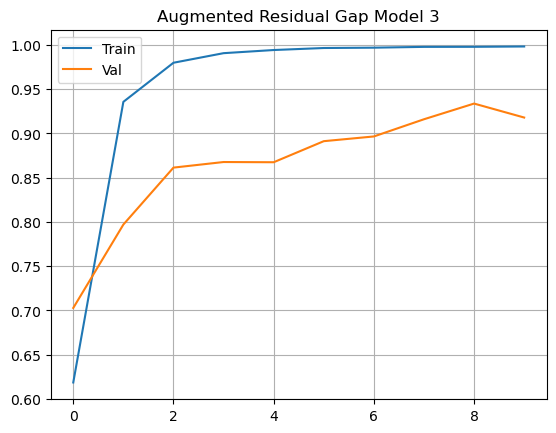

In [250]:
plt.figure()
plt.plot(gap_aug3_train, label="Train")
plt.plot(gap_aug3_val, label="Val")
plt.title("Augmented Residual Gap Model 3")
plt.legend()
plt.grid()
plt.show()

In [265]:
# Summary of all the models and their accuracy scores and everything.
models = {
    "BaseCNN": base_cnn,
    "DropoutCNN": cnn_dropout,
    "ReLUCNN": cnn_relu,
    "WideCNN": cnn_wide,
    "DeepCNN": cnn_deep,
    "GAPCNN": cnn_gap,
    "ResidualGAPCNN": cnn_residual_gap,
    "ResidualGAPCNN_Aug1": cnn_gap_aug,
    "ResidualGAPCNN_Aug2": cnn_gap_aug2,
    "ResidualGAPCNN_Aug3": cnn_gap_aug3  
}

best_val_scores = {
    "BaseCNN": base_best_val,
    "DropoutCNN": best_dropout_val,
    "ReLUCNN": best_relu_val,
    "WideCNN": best_wide_val,
    "DeepCNN": best_deep_val,
    "GAPCNN": best_gap_val,
    "ResidualGAPCNN": res_gap_val,
    "ResidualGAPCNN_Aug1": best_gap_aug_val, 
    "ResidualGAPCNN_Aug2": best_gap_aug2_val,
    "ResidualGAPCNN_Aug3": best_gap_aug3_val,
}

best_val_scores_fixed = {k: max(v) if isinstance(v, list) else v for k, v in best_val_scores.items()}

param_counts = {
    name: count_params(model) for name, model in models.items()
}

df = pd.DataFrame({
    "Model": list(best_val_scores_fixed.keys()),
    "Validation Accuracy": [best_val_scores_fixed[m] for m in best_val_scores_fixed.keys()],
    "Parameters": [param_counts[m] for m in best_val_scores_fixed.keys()]
})

df = df.sort_values(by="Validation Accuracy", ascending=False)
print("Model Summary Table:")
print(df)

ranked_models = df[["Model", "Validation Accuracy"]].values.tolist()
print("\nRanked Models by Validation Accuracy:")
for rank, (name, val_acc) in enumerate(ranked_models, start=1):
    print(f"{rank}. {name}: {val_acc:.4f}")

best_model_name = df.iloc[0]["Model"]
best_model_val = df.iloc[0]["Validation Accuracy"]
best_model = models[best_model_name]

print(f"\nBest model based on validation accuracy: {best_model_name} ({best_model_val:.4f})")
test_accuracy = test_model(best_model)
print("Test Accuracy of Best Model:", test_accuracy)



Model Summary Table:
                 Model  Validation Accuracy  Parameters
3              WideCNN             0.999514       56809
0              BaseCNN             0.996116       27193
4              DeepCNN             0.988832       17041
6       ResidualGAPCNN             0.966982       11969
2              ReLUCNN             0.959213       27193
1           DropoutCNN             0.936392       27193
9  ResidualGAPCNN_Aug3             0.933722       11969
5               GAPCNN             0.907016        6713
8  ResidualGAPCNN_Aug2             0.842437       11969
7  ResidualGAPCNN_Aug1             0.826900       11969

Ranked Models by Validation Accuracy:
1. WideCNN: 0.9995
2. BaseCNN: 0.9961
3. DeepCNN: 0.9888
4. ResidualGAPCNN: 0.9670
5. ReLUCNN: 0.9592
6. DropoutCNN: 0.9364
7. ResidualGAPCNN_Aug3: 0.9337
8. GAPCNN: 0.9070
9. ResidualGAPCNN_Aug2: 0.8424
10. ResidualGAPCNN_Aug1: 0.8269

Best model based on validation accuracy: WideCNN (0.9995)
Test Accuracy: 0.978667038482

/var/folders/j3/hccr8hqj7_j4q6tvlq8724cm0000gn/T/ipykernel_17633/2481605320.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(df["Model"], rotation=45, ha="right")
/var/folders/j3/hccr8hqj7_j4q6tvlq8724cm0000gn/T/ipykernel_17633/2481605320.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(df["Model"], rotation=45, ha="right")


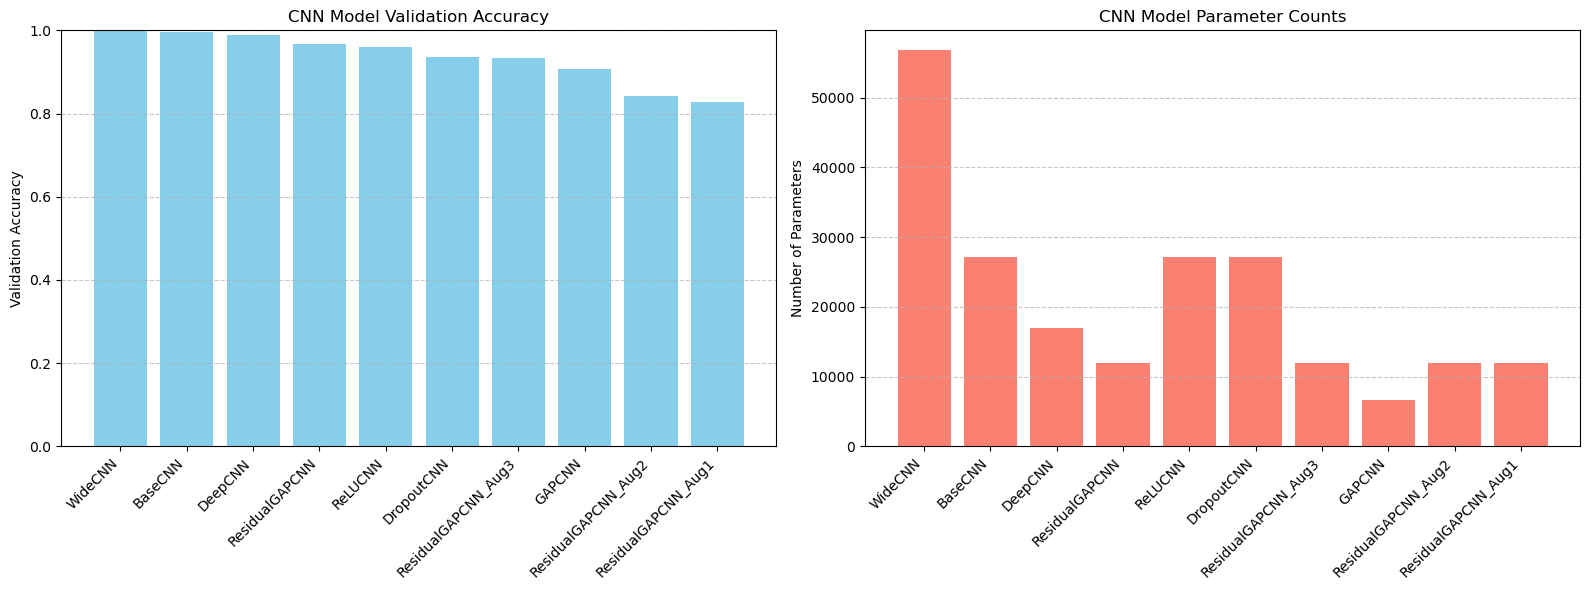

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  

# Validation Accuracy subplot
axes[0].bar(df["Model"], df["Validation Accuracy"], color="skyblue")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("CNN Model Validation Accuracy")
axes[0].set_xticklabels(df["Model"], rotation=45, ha="right")
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Parameter Counts subplot
axes[1].bar(df["Model"], df["Parameters"], color="salmon")
axes[1].set_ylabel("Number of Parameters")
axes[1].set_title("CNN Model Parameter Counts")
axes[1].set_xticklabels(df["Model"], rotation=45, ha="right")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

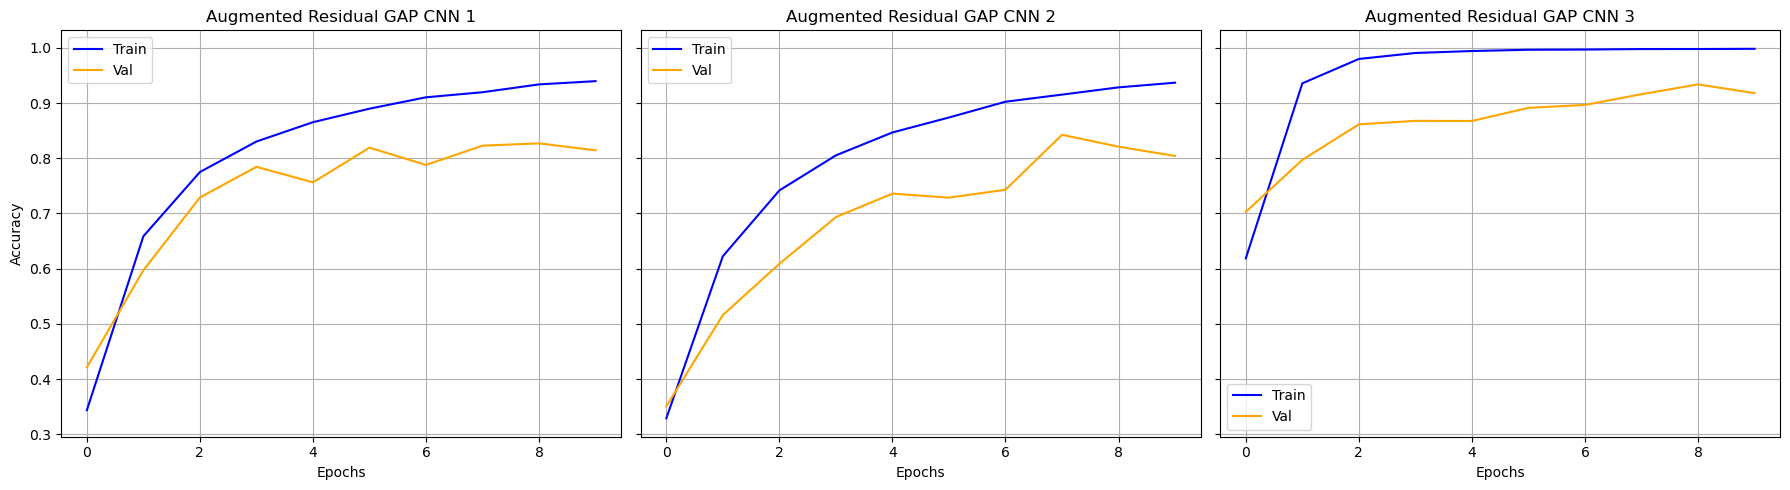

In [ ]:
# Plotting the 3 Augmentation models under one plot.

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Augmented Residual GAP 1
axes[0].plot(gap_aug_train, label="Train", color='blue')
axes[0].plot(gap_aug_val, label="Val", color='orange')
axes[0].set_title("Augmented Residual GAP CNN 1")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Augmented Residual GAP 2
axes[1].plot(gap_aug2_train, label="Train", color='blue')
axes[1].plot(gap_aug2_val, label="Val", color='orange')
axes[1].set_title("Augmented Residual GAP CNN 2")
axes[1].set_xlabel("Epochs")
axes[1].legend()
axes[1].grid(True)

# Augmented Residual GAP 3
axes[2].plot(gap_aug3_train, label="Train", color='blue')
axes[2].plot(gap_aug3_val, label="Val", color='orange')
axes[2].set_title("Augmented Residual GAP CNN 3")
axes[2].set_xlabel("Epochs")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

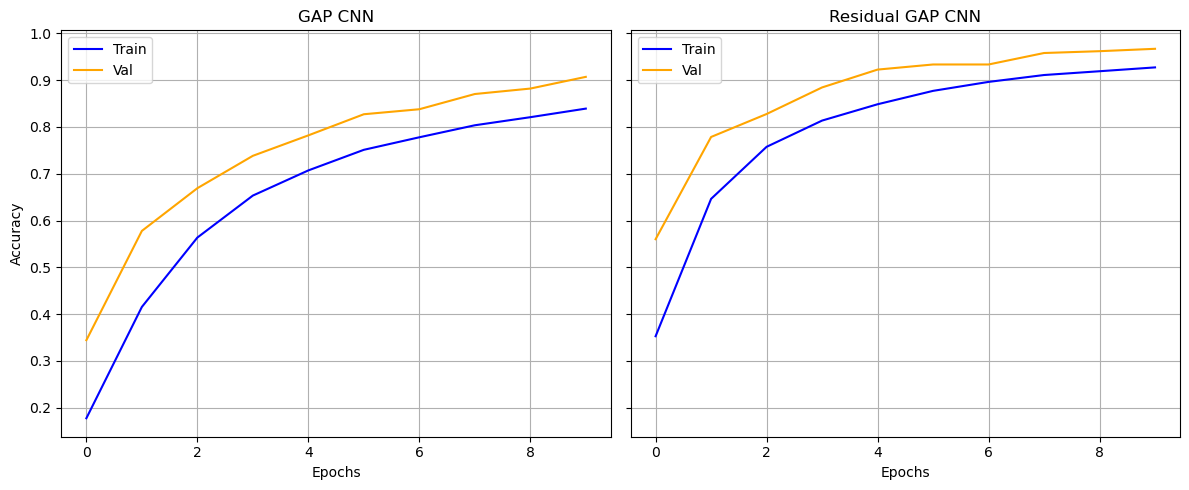

In [264]:
#Plotting the GAP models under one plot.

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# GAP CNN
axes[0].plot(gap_train, label="Train", color='blue')
axes[0].plot(gap_val, label="Val", color='orange')
axes[0].set_title("GAP CNN")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Residual GAP CNN
axes[1].plot(res_gap_train, label="Train", color='blue')
axes[1].plot(res_gap_val, label="Val", color='orange')
axes[1].set_title("Residual GAP CNN")
axes[1].set_xlabel("Epochs")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()